In [1]:
# 01.09.2026 - Watek 3 z planu 20260831/20260831_plan.md (punkt otwarty po
# 31.08): ILE Z 20 STACJI TO NAPRAWDE NIEZALEZNE INFORMACJE (k_eff).
#
# Kontekst. 31.08 (20260831b.ipynb, Krok 7) wyszlo, ze po karze za
# wielokrotne proby i po odebraniu stacjom swobody wyboru punktu w oknie
# erowym tylko 2 z 20 stacji (aatb, hrms) trzymaja sie powyzej istotnosci
# artykulu (6.3 sigma). Zeby ta liczba cokolwiek znaczyla, trzeba
# odpowiedziec na dwa pytania:
#   (1) ile w tej sieci jest NAPRAWDE niezaleznych stacji - wszystkie widza
#       ten sam cykl sloneczny (korelacje surowych CR 0.6-0.9 zmierzone
#       26.08) i wszystkie uzywaja TEGO SAMEGO katalogu trzesien;
#   (2) czy akurat aatb i hrms nie sa dwiema kopiami tej samej informacji -
#       jesli tak, to "2 z 20" nie jest dwoma niezaleznymi potwierdzeniami.
# Dodatkowo: "najlepsza z 20 stacji" to samo w sobie jest wyborem z
# wielokrotnych prob, ktory nigdzie dotad nie zostal oplacony (ostatnia
# komorka tego notebooka).
#
# WEJSCIE - wylacznie juz policzone pliki, zero skanow, zero zapytan do
# NMDB/USGS:
#   results/finetune_{stacja}_P3350_d5_dt15_fullhistory.csv   (26.08)
#   results/station_cross_correlation.csv                     (26.08, surowe CR)
#   results/section4_penalized_significance_stale_punkty.csv  (31.08)
#   data/nmdb_station_coordinates.csv
#
# METODA (plan, Watek 3, krok 1-2). Korelujemy NIE surowe dane CR, tylko
# KRZYWE WYNIKOW -log10(PPDF) w funkcji t0 (caly "krajobraz" skanu) - bo
# interesuje nas niezaleznosc WNIOSKOW, nie pomiarow. Nastepnie
#     k_eff = (suma lambda_i)^2 / suma(lambda_i^2)
# z widma wartosci wlasnych macierzy korelacji. Interpretacja: k_eff = k
# dla k stacji zupelnie niezaleznych, k_eff = 1 dla k stacji identycznych.
# To standardowa miara efektywnej liczby wymiarow (participation ratio).
import numpy as np
import pandas as pd
from scipy.stats import norm, spearmanr

RESULTS_DIR = "../results"
DATA_DIR = "../data"

STATIONS = [
    "aatb", "apty", "athn", "fsmt", "hrms", "invk", "jung", "jung1",
    "lmks", "mosc", "mxco", "nain", "newk", "oulu", "psnm", "pwnk",
    "sopb", "sopo", "tera", "thul",
]

P_DAYS = 3350
D_DAYS = 5
STEP_HOURS = 6  # krok siatki t0 w skanie 26.08
SAMPLES_PER_YEAR = 365.25 * 24 / STEP_HOURS

curves = {}
for st in STATIONS:
    path = f"{RESULTS_DIR}/finetune_{st}_P{P_DAYS}_d{D_DAYS}_dt15_fullhistory.csv"
    df = pd.read_csv(path, parse_dates=["t0"]).sort_values("t0")
    y = -np.log10(df["PPDF"].to_numpy())
    s = pd.Series(y, index=df["t0"].to_numpy())
    s = s[np.isfinite(s.to_numpy())]
    curves[st] = s[~s.index.duplicated(keep="first")]

# DataFrame z dict-a Series laczy sie po SUMIE indeksow (outer join); wszystkie
# siatki t0 leza na pelnych wielokrotnosciach 6h od polnocy, wiec punkty
# roznych stacji trafiaja na te same znaczniki czasu, a nie obok siebie.
landscape = pd.DataFrame(curves).sort_index()
print(f"Krajobraz skanu: {landscape.shape[0]} znacznikow czasu x {landscape.shape[1]} stacji")
print(f"Zakres: {landscape.index.min()} .. {landscape.index.max()}")
print()
print("Pokrycie per stacja (liczba punktow, poczatek, koniec):")
for st in STATIONS:
    s = landscape[st]
    print(f"  {st:6s} {s.notna().sum():7d}  {s.first_valid_index().date()} .. {s.last_valid_index().date()}")


Krajobraz skanu: 74322 znacznikow czasu x 20 stacji
Zakres: 1965-01-01 12:00:00 .. 2015-11-15 18:00:00

Pokrycie per stacja (liczba punktow, poczatek, koniec):
  aatb     62636  1973-01-01 .. 2015-11-15
  apty     22464  2000-07-01 .. 2015-11-15
  athn     21933  2000-11-10 .. 2015-11-15
  fsmt     22084  2000-10-04 .. 2015-11-15
  hrms     69752  1965-01-01 .. 2012-09-29
  invk     23192  2000-01-01 .. 2015-11-15
  jung     74322  1965-01-01 .. 2015-11-15
  jung1    43644  1986-01-01 .. 2015-11-15
  lmks     47388  1981-12-01 .. 2014-05-08
  mosc     74322  1965-01-01 .. 2015-11-15
  mxco     37800  1990-01-01 .. 2015-11-15
  nain     21933  2000-11-10 .. 2015-11-15
  newk     74322  1965-01-01 .. 2015-11-15
  oulu     67020  1970-01-01 .. 2015-11-15
  psnm     11596  2007-12-09 .. 2015-11-15
  pwnk     22164  2000-09-14 .. 2015-11-15
  sopb     26116  1997-12-31 .. 2015-11-15
  sopo     74322  1965-01-01 .. 2015-11-15
  tera     69460  1968-05-01 .. 2015-11-15
  thul     74322  1965-

In [2]:
# Krok 1: macierz korelacji krzywych -log10(PPDF) miedzy parami stacji.
# Tylko pary z sensownym wspolnym pokryciem (>= MIN_OVERLAP_YEARS lat) -
# reszta jako NaN (plan, Watek 3 krok 1). pandas liczy korelacje parami na
# obserwacjach wspolnych dla danej pary (pairwise complete), a min_periods
# wycina pary o zbyt malym nakladaniu.
MIN_OVERLAP_YEARS = 5.0
MIN_OVERLAP_SAMPLES = int(round(MIN_OVERLAP_YEARS * SAMPLES_PER_YEAR))

corr_landscape = landscape.corr(method="pearson", min_periods=MIN_OVERLAP_SAMPLES)

mask = landscape.notna().astype(int)
overlap_samples = mask.T.dot(mask)
overlap_years = overlap_samples / SAMPLES_PER_YEAR

corr_landscape.to_csv(f"{RESULTS_DIR}/station_landscape_correlation.csv")
overlap_years.round(2).to_csv(f"{RESULTS_DIR}/station_landscape_overlap_years.csv")
print(f"Zapisano {RESULTS_DIR}/station_landscape_correlation.csv")
print(f"Zapisano {RESULTS_DIR}/station_landscape_overlap_years.csv")

iu = np.triu_indices(len(STATIONS), k=1)
pary = pd.DataFrame({
    "stacja_a": np.array(STATIONS)[iu[0]],
    "stacja_b": np.array(STATIONS)[iu[1]],
    "korelacja_krajobrazu": corr_landscape.to_numpy()[iu],
    "wspolne_lata": overlap_years.to_numpy()[iu],
})
print()
print(f"Par stacji lacznie: {len(pary)}; z pokryciem >= {MIN_OVERLAP_YEARS} lat: "
      f"{pary['korelacja_krajobrazu'].notna().sum()}")
print(f"Korelacja krzywych -log10 PPDF: mediana={pary['korelacja_krajobrazu'].median():.3f}, "
      f"min={pary['korelacja_krajobrazu'].min():.3f}, max={pary['korelacja_krajobrazu'].max():.3f}")


Zapisano ../results/station_landscape_correlation.csv
Zapisano ../results/station_landscape_overlap_years.csv

Par stacji lacznie: 190; z pokryciem >= 5.0 lat: 189
Korelacja krzywych -log10 PPDF: mediana=0.651, min=-0.242, max=0.906


In [3]:
# Krok 2: k_eff z widma wartosci wlasnych. Liczone na PELNYCH przypadkach
# (complete case): dla zadanego podzbioru stacji bierzemy tylko te
# znaczniki czasu, w ktorych KAZDA stacja podzbioru ma wartosc - dzieki
# temu macierz jest policzona na jednym, wspolnym oknie czasu i jest
# porzadna (dodatnio okreslona), bez sztuczek na NaN-ach.
#
# Podzbiory (wymuszone struktura danych - patrz pokrycie w komorce 0):
# wszystkie 20 stacji ma wspolne okno dopiero od startu psnm (2007-12) do
# konca hrms (2012-09), czyli ~5 lat. Zeby nie ocenic k_eff na jednym
# krotkim wycinku, liczymy tez podzbiory dluzsze: bez psnm, bez psnm+hrms
# oraz "stare" stacje z historia od lat 70.
def k_eff_from_corr(C):
    lam = np.linalg.eigvalsh(np.asarray(C, dtype=float))
    lam = np.clip(lam, 0.0, None)  # numeryczne "-1e-16" -> 0
    return float(lam.sum() ** 2 / (lam ** 2).sum()), np.sort(lam)[::-1]


# UWAGA: wspolne okno WSZYSTKICH 20 stacji ma ok. 4,8 roku (od startu psnm
# 2007-12 do konca hrms 2012-09), czyli TUZ PONIZEJ progu 5 lat uzytego przy
# macierzy par. Dlatego podzbiory maja wlasny, nizszy prog - inaczej
# najwazniejszy podzbior (wszystkie 20) wypadlby z tabeli.
MIN_OKNO_LAT_PODZBIORU = 4.0
MIN_OKNO_PROBEK = int(round(MIN_OKNO_LAT_PODZBIORU * SAMPLES_PER_YEAR))


def analiza_podzbioru(stacje):
    blok = landscape[list(stacje)].dropna()
    if len(blok) < MIN_OKNO_PROBEK:
        return None
    C = blok.corr()
    k, lam = k_eff_from_corr(C)
    iu_s = np.triu_indices(len(stacje), k=1)
    return dict(
        n_stacji=len(stacje),
        okno_start=blok.index.min(), okno_koniec=blok.index.max(),
        dlugosc_okna_lat=(blok.index.max() - blok.index.min()).days / 365.25,
        n_punktow=len(blok),
        srednia_korelacja=float(C.to_numpy()[iu_s].mean()),
        k_eff=k, C=C, lam=lam,
    )


starts = {st: landscape[st].first_valid_index() for st in STATIONS}
dlugie = sorted([st for st in STATIONS if starts[st] <= pd.Timestamp("1975-01-01")])

PODZBIORY = {
    "wszystkie_20": STATIONS,
    "19_bez_psnm": [s for s in STATIONS if s != "psnm"],
    "18_bez_psnm_hrms": [s for s in STATIONS if s not in ("psnm", "hrms")],
    "dlugie_od_1975": dlugie,
    "dlugie_bez_hrms": [s for s in dlugie if s != "hrms"],
}

wyniki_keff = {}
rows = []
for nazwa, stacje in PODZBIORY.items():
    res = analiza_podzbioru(stacje)
    wyniki_keff[nazwa] = res
    if res is None:
        print(f"{nazwa}: brak wspolnego okna >= {MIN_OKNO_LAT_PODZBIORU} lat - pominiete")
        continue
    rows.append(dict(podzbior=nazwa, n_stacji=res["n_stacji"],
                     okno_start=res["okno_start"].date(), okno_koniec=res["okno_koniec"].date(),
                     dlugosc_okna_lat=round(res["dlugosc_okna_lat"], 1),
                     srednia_korelacja=round(res["srednia_korelacja"], 3),
                     k_eff=round(res["k_eff"], 2),
                     k_eff_na_stacje=round(res["k_eff"] / res["n_stacji"], 3)))

keff_table = pd.DataFrame(rows)
keff_table.to_csv(f"{RESULTS_DIR}/station_landscape_keff.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/station_landscape_keff.csv")
print()
print(keff_table.to_string(index=False))
print()
print("Czytanie tabeli: k_eff = efektywna liczba niezaleznych stacji. Kolumna")
print("k_eff_na_stacje blisko 1.0 oznaczalaby siec faktycznie niezaleznych")
print("detektorow, blisko 0 - siec powielajaca jedna te sama informacje.")


Zapisano ../results/station_landscape_keff.csv

        podzbior  n_stacji okno_start okno_koniec  dlugosc_okna_lat  srednia_korelacja  k_eff  k_eff_na_stacje
    wszystkie_20        20 2007-12-09  2012-09-29               4.8              0.678   1.90            0.095
     19_bez_psnm        19 2000-11-10  2012-09-29              11.9              0.586   2.24            0.118
18_bez_psnm_hrms        18 2000-11-10  2014-05-08              13.5              0.554   2.44            0.136
  dlugie_od_1975         9 1973-01-01  2012-09-29              39.7              0.633   1.99            0.221
 dlugie_bez_hrms         8 1973-01-01  2015-11-15              42.9              0.584   2.18            0.273

Czytanie tabeli: k_eff = efektywna liczba niezaleznych stacji. Kolumna
k_eff_na_stacje blisko 1.0 oznaczalaby siec faktycznie niezaleznych
detektorow, blisko 0 - siec powielajaca jedna te sama informacje.


In [4]:
# Krok 3: porownanie z korelacja SUROWYCH danych CR (results/
# station_cross_correlation.csv, policzone 26.08). Pytanie z planu (Watek 3
# krok 3): czy krzywe WYNIKOW sa bardziej, czy mniej zbiezne niz same
# pomiary? Jesli krajobrazy sa wyraznie mniej skorelowane niz surowe CR, to
# znaczy, ze statystyka cosmoseismic_stat wydobywa z kazdej stacji cos
# wlasnego. Jesli tak samo lub bardziej - wyniki sa w duzej mierze
# przepisaniem tej samej modulacji slonecznej.
corr_cr = pd.read_csv(f"{RESULTS_DIR}/station_cross_correlation.csv", index_col=0)
corr_cr = corr_cr.loc[STATIONS, STATIONS]

pary["korelacja_surowe_CR"] = corr_cr.to_numpy()[iu]
por = pary.dropna(subset=["korelacja_krajobrazu", "korelacja_surowe_CR"])
rho, pval = spearmanr(por["korelacja_krajobrazu"], por["korelacja_surowe_CR"])

print(f"Pary z obiema korelacjami: {len(por)}")
print(f"Mediana korelacji SUROWYCH CR:        {por['korelacja_surowe_CR'].median():.3f}")
print(f"Mediana korelacji KRAJOBRAZOW wynikow: {por['korelacja_krajobrazu'].median():.3f}")
print(f"Zwiazek miedzy nimi (Spearman): rho={rho:.3f}, p={pval:.2e}")

pary.sort_values("korelacja_krajobrazu", ascending=False).to_csv(
    f"{RESULTS_DIR}/station_landscape_pairs.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/station_landscape_pairs.csv")


Pary z obiema korelacjami: 189
Mediana korelacji SUROWYCH CR:        0.784
Mediana korelacji KRAJOBRAZOW wynikow: 0.651
Zwiazek miedzy nimi (Spearman): rho=0.235, p=1.11e-03
Zapisano ../results/station_landscape_pairs.csv


In [5]:
# Krok 4: pary wspolokolowane i para "zwyciezcow". Punkt z planu (Watek 3
# krok 4): w zadnym dotychczasowym podsumowaniu nie bylo powiedziane, ze
# jung/jung1 to ta sama gora (Jungfraujoch, identyczne wspolrzedne w
# data/nmdb_station_coordinates.csv), a sopo/sopb to ten sam biegun
# poludniowy. Do tego sprawdzamy aatb-hrms, czyli dwie stacje, ktore 31.08
# jako jedyne przekroczyly 6.3 sigma.
coords = pd.read_csv(f"{DATA_DIR}/nmdb_station_coordinates.csv").set_index("station")

PARY_KONTROLNE = [
    ("jung", "jung1", "ten sam szczyt Jungfraujoch"),
    ("sopo", "sopb", "ten sam biegun poludniowy"),
    ("aatb", "hrms", "dwie stacje, ktore 31.08 przekroczyly 6.3 sigma"),
]

for a, b, opis in PARY_KONTROLNE:
    kraj = corr_landscape.loc[a, b]
    cr = corr_cr.loc[a, b]
    lata = overlap_years.loc[a, b]
    d_lat = coords.loc[a, "lat"] - coords.loc[b, "lat"]
    d_lon = coords.loc[a, "lon"] - coords.loc[b, "lon"]
    print(f"{a}-{b} ({opis}):")
    print(f"    wspolrzedne: {a} ({coords.loc[a, 'lat']}, {coords.loc[a, 'lon']}), "
          f"{b} ({coords.loc[b, 'lat']}, {coords.loc[b, 'lon']})  "
          f"roznica ({d_lat:+.2f}, {d_lon:+.2f})")
    print(f"    korelacja surowych CR:      {cr:.3f}")
    print(f"    korelacja krajobrazu wynikow: {kraj if pd.isna(kraj) else round(kraj, 3)}"
          f"   (wspolne lata: {lata:.1f})")

print()
print("Dziesiec najsilniej skorelowanych par krajobrazow:")
print(pary.dropna(subset=["korelacja_krajobrazu"])
          .sort_values("korelacja_krajobrazu", ascending=False)
          .head(10).to_string(index=False))


jung-jung1 (ten sam szczyt Jungfraujoch):
    wspolrzedne: jung (46.55, 7.98), jung1 (46.55, 7.98)  roznica (+0.00, +0.00)
    korelacja surowych CR:      0.689
    korelacja krajobrazu wynikow: 0.493   (wspolne lata: 29.9)
sopo-sopb (ten sam biegun poludniowy):
    wspolrzedne: sopo (-90.0, 0.0), sopb (-90.0, 0.0)  roznica (+0.00, +0.00)
    korelacja surowych CR:      0.947
    korelacja krajobrazu wynikow: 0.203   (wspolne lata: 17.9)
aatb-hrms (dwie stacje, ktore 31.08 przekroczyly 6.3 sigma):
    wspolrzedne: aatb (43.14, 76.6), hrms (-34.43, 19.23)  roznica (+77.57, +57.37)
    korelacja surowych CR:      0.930
    korelacja krajobrazu wynikow: 0.724   (wspolne lata: 39.7)

Dziesiec najsilniej skorelowanych par krajobrazow:
stacja_a stacja_b  korelacja_krajobrazu  wspolne_lata  korelacja_surowe_CR
    hrms     invk              0.905901     12.746064             0.589393
    fsmt     hrms              0.905227     11.987680             0.846049
    invk     thul              0.89

Zapisano ../results/station_landscape_correlation_matrix.png


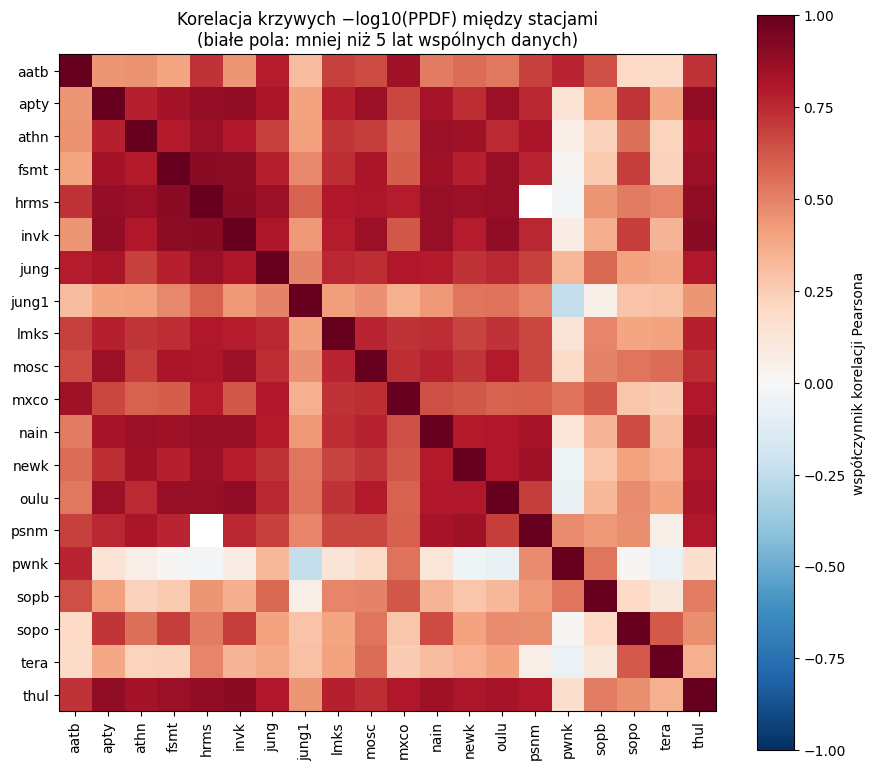

In [6]:
# Wykres 1 (jedno kodowanie: kolor = korelacja): macierz korelacji
# krajobrazow -log10 PPDF. Pola biale = para bez wystarczajacego wspolnego
# pokrycia (< 5 lat), czyli brak informacji, a nie zerowa korelacja.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))
M = corr_landscape.loc[STATIONS, STATIONS].to_numpy()
im = ax.imshow(np.ma.masked_invalid(M), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(STATIONS)))
ax.set_xticklabels(STATIONS, rotation=90)
ax.set_yticks(range(len(STATIONS)))
ax.set_yticklabels(STATIONS)
ax.set_title("Korelacja krzywych −log10(PPDF) między stacjami\n"
             "(białe pola: mniej niż 5 lat wspólnych danych)")
fig.colorbar(im, ax=ax, label="współczynnik korelacji Pearsona")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_landscape_correlation_matrix.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/station_landscape_correlation_matrix.png")


Zapisano ../results/station_landscape_eigenvalues.png


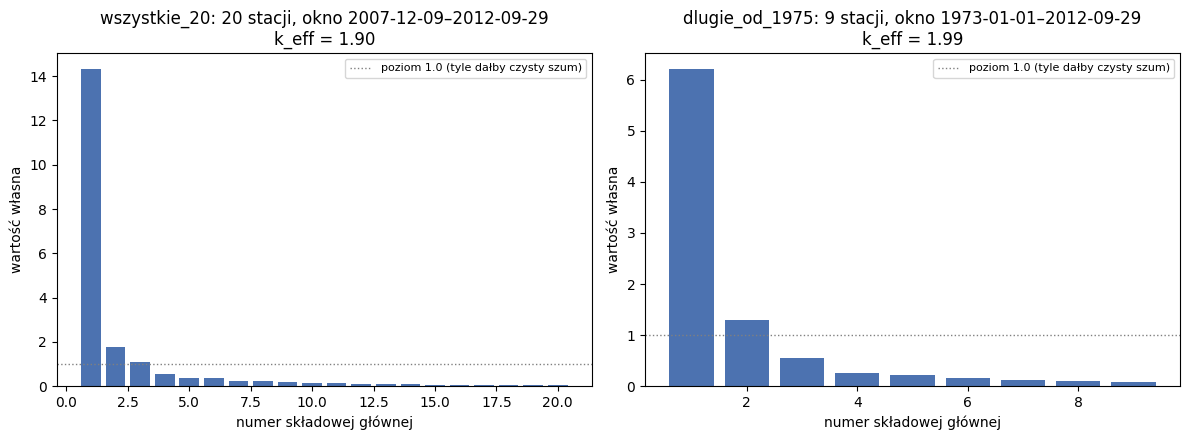

In [7]:
# Wykres 2 (jedno kodowanie: wysokosc slupka = wartosc wlasna): widmo
# macierzy korelacji dla dwoch podzbiorow, z zaznaczonym k_eff. Pierwsza
# wartosc wlasna blisko liczby stacji = jeden wspolny tryb dominuje cala
# siec.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, nazwa in zip(axes, ["wszystkie_20", "dlugie_od_1975"]):
    res = wyniki_keff[nazwa]
    if res is None:
        ax.set_visible(False)
        continue
    lam = res["lam"]
    ax.bar(np.arange(1, len(lam) + 1), lam, color="#4C72B0")
    ax.axhline(1.0, color="gray", ls=":", lw=1,
               label="poziom 1.0 (tyle dałby czysty szum)")
    ax.set_xlabel("numer składowej głównej")
    ax.set_ylabel("wartość własna")
    ax.set_title(f"{nazwa}: {res['n_stacji']} stacji, okno "
                 f"{res['okno_start'].date()}–{res['okno_koniec'].date()}\n"
                 f"k_eff = {res['k_eff']:.2f}")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_landscape_eigenvalues.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/station_landscape_eigenvalues.png")


Zapisano ../results/station_landscape_vs_cr_correlation.png


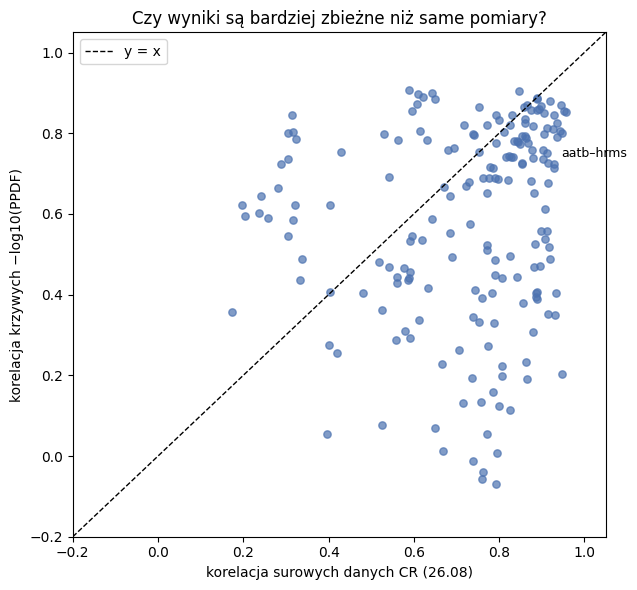

In [8]:
# Wykres 3 (jedno kodowanie: polozenie punktu): korelacja surowych CR
# kontra korelacja krajobrazow wynikow, para po parze. Linia y=x oddziela
# obszar "wyniki bardziej zbiezne niz pomiary" (nad linia) od "statystyka
# wydobywa cos wlasnego z kazdej stacji" (pod linia).
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(por["korelacja_surowe_CR"], por["korelacja_krajobrazu"],
           s=28, alpha=0.7, color="#4C72B0")
lim = [-0.2, 1.05]
ax.plot(lim, lim, color="black", ls="--", lw=1, label="y = x")
for _, r in por.iterrows():
    if r["stacja_a"] in ("aatb", "hrms") and r["stacja_b"] in ("aatb", "hrms"):
        ax.annotate(f"{r['stacja_a']}–{r['stacja_b']}",
                    (r["korelacja_surowe_CR"], r["korelacja_krajobrazu"]),
                    fontsize=9, xytext=(5, 5), textcoords="offset points")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("korelacja surowych danych CR (26.08)")
ax.set_ylabel("korelacja krzywych −log10(PPDF)")
ax.set_title("Czy wyniki są bardziej zbieżne niż same pomiary?")
ax.legend()
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_landscape_vs_cr_correlation.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/station_landscape_vs_cr_correlation.png")


In [9]:
# Krok 5: przeliczenie naglowka 31.08 na poziom SIECI. Do tej pory kazda
# stacja miala wlasne post-trial sigma (20260831b.ipynb, Krok 7), ale sam
# fakt wybrania NAJLEPSZEJ stacji z sieci jest kolejna, nieoplacona proba.
# Poprawka Sidaka na k_eff niezaleznych prob:
#     p_siec = 1 - (1 - p_stacja)^k_eff
# Uzywamy k_eff z dwoch podzbiorow jako widelek. Zastrzezenie zapisane tez
# w druku ponizej: przy dodatnio skorelowanych stacjach Sidak jest
# KONSERWATYWNY (kara nieco za duza), a k_eff jest miara przyblizona - to
# gorne oszacowanie kary, nie dokladny rachunek.
pen = pd.read_csv(f"{RESULTS_DIR}/section4_penalized_significance_stale_punkty.csv")
pen = pen[pen["product"].notna()].copy()

def keff_lub_zastepczy(nazwa, zastepcze):
    # jesli danego podzbioru nie dalo sie policzyc (za krotkie wspolne okno),
    # bierzemy pierwszy dostepny z listy zastepczych i mowimy o tym wprost -
    # cicha zamiana na NaN kasowala cala kolumne kary (blad z 01.09)
    res = wyniki_keff.get(nazwa)
    if res is not None:
        return res["k_eff"], nazwa
    for alt in zastepcze:
        res = wyniki_keff.get(alt)
        if res is not None:
            print(f"UWAGA: podzbior '{nazwa}' niepoliczalny - uzyto '{alt}'")
            return res["k_eff"], alt
    raise RuntimeError("zaden podzbior nie dal sie policzyc - sprawdz komorke 2")


k_all, zrodlo_all = keff_lub_zastepczy("wszystkie_20", ["19_bez_psnm", "18_bez_psnm_hrms"])
k_long, zrodlo_long = keff_lub_zastepczy("dlugie_od_1975", ["dlugie_bez_hrms"])
print(f"k_eff uzyty do kary: {k_all:.2f} (podzbior {zrodlo_all}) "
      f"oraz {k_long:.2f} (podzbior {zrodlo_long})")

def sidak(p, k):
    # 1-(1-p)^k liczone wprost TRACI CALA PRECYZJE dla malych p: dla p<~1e-16
    # (1-p)^k zaokragla sie do 1.0 i wychodzi p_siec=0, czyli sigma=inf.
    # Tak wlasnie stalo sie 01.09 dla hrms w wariancie (b) (p~1e-24).
    # Postac rownowazna, ale stabilna: -expm1(k*log1p(-p)).
    p = np.asarray(p, dtype=float)
    out = np.full(p.shape, np.nan)
    ok = np.isfinite(p) & (p > 0) & (p < 1)
    out[ok] = -np.expm1(k * np.log1p(-p[ok]))
    return out


for nazwa, k in [("k_eff_wszystkie_20", k_all), ("k_eff_dlugie", k_long)]:
    p_net = sidak(pen["product"].to_numpy(), k)
    pen[nazwa] = round(k, 2)
    pen[f"sigma_siec_{nazwa}"] = np.where(np.isfinite(p_net), norm.isf(p_net), np.nan)

# lancuchy o iloczynie >= 1 (brak wyniku) zostaja jawnym NaN, a nie -inf
bez_wyniku = pen[~np.isfinite(pen["sigma_siec_k_eff_wszystkie_20"])]["station"].tolist()
if bez_wyniku:
    print(f"Stacje bez wyniku po karze (iloczyn >= 1, lancuch nic nie daje): {bez_wyniku}")

pen = pen.sort_values(["wariant", "sigma_post_trial"], ascending=[True, False])
pen.to_csv(f"{RESULTS_DIR}/section4_network_level_significance.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/section4_network_level_significance.csv")
print()
kolumny = ["station", "wariant", "n_minima", "sigma_post_trial",
           "sigma_siec_k_eff_wszystkie_20", "sigma_siec_k_eff_dlugie"]
print(pen[kolumny].round(2).to_string(index=False))
print()
print("sigma_post_trial   - wynik z 31.08 (kara tylko za skan po t0)")
print("sigma_siec_...     - dodatkowo kara za wybor najlepszej stacji z sieci")


k_eff uzyty do kary: 1.90 (podzbior wszystkie_20) oraz 1.99 (podzbior dlugie_od_1975)
Stacje bez wyniku po karze (iloczyn >= 1, lancuch nic nie daje): ['jung1', 'jung1']
Zapisano ../results/section4_network_level_significance.csv

station           wariant  n_minima  sigma_post_trial  sigma_siec_k_eff_wszystkie_20  sigma_siec_k_eff_dlugie
   hrms  a_z_wykluczeniem         4              7.40                           7.31                     7.31
   aatb  a_z_wykluczeniem         3              6.45                           6.35                     6.35
   newk  a_z_wykluczeniem         4              4.41                           4.27                     4.26
   thul  a_z_wykluczeniem         4              4.18                           4.03                     4.02
   mosc  a_z_wykluczeniem         4              4.12                           3.96                     3.95
   jung  a_z_wykluczeniem         4              4.07                           3.91                     3.90

Zapisano ../results/section4_network_level_significance.png


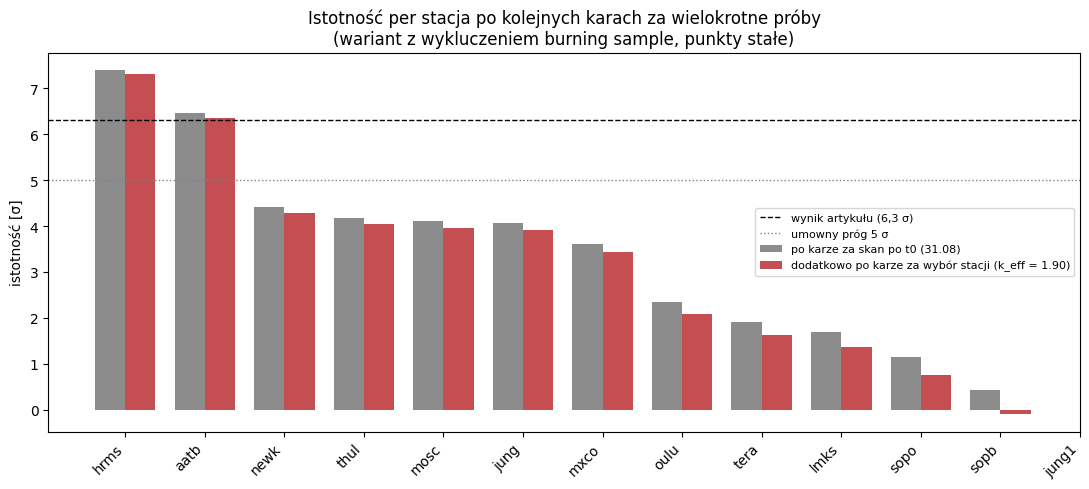

In [10]:
# Wykres 4 (jedno kodowanie: wysokosc slupka = sigma): ile zostaje z
# wyniku 31.08 po doliczeniu kary za wybor stacji. Tylko wariant (a)
# (przepis artykulu: minima sprzed burning sample) - wariant (b) jest w
# zapisanym CSV.
sub = pen[(pen["wariant"] == "a_z_wykluczeniem") & (pen["n_minima"] > 0)].sort_values(
    "sigma_post_trial", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(sub))
w = 0.38
ax.bar(x - w / 2, sub["sigma_post_trial"], w,
       label="po karze za skan po t0 (31.08)", color="#8C8C8C")
ax.bar(x + w / 2, sub["sigma_siec_k_eff_wszystkie_20"], w,
       label=f"dodatkowo po karze za wybór stacji (k_eff = {k_all:.2f})", color="#C44E52")
ax.axhline(6.3, color="black", ls="--", lw=1, label="wynik artykułu (6,3 σ)")
ax.axhline(5.0, color="gray", ls=":", lw=1, label="umowny próg 5 σ")
ax.set_xticks(x)
ax.set_xticklabels(sub["station"], rotation=45, ha="right")
ax.set_ylabel("istotność [σ]")
ax.set_title("Istotność per stacja po kolejnych karach za wielokrotne próby\n"
             "(wariant z wykluczeniem burning sample, punkty stałe)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/section4_network_level_significance.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/section4_network_level_significance.png")


In [11]:
# Podsumowanie watku - jawnie wypisane, zeby przepisac do dziennika bez
# przegladania calego notebooka. Wszystkie liczby ponizej pochodza z
# obliczen w tym notebooku (zadna nie jest wpisana z reki).
print("=" * 70)
print("WATEK 3 (k_eff) - PODSUMOWANIE")
print("=" * 70)
print()
print("1. Efektywna liczba niezaleznych stacji (k_eff):")
for _, r in keff_table.iterrows():
    print(f"   {r['podzbior']:20s} {r['n_stacji']:2d} stacji, okno {r['dlugosc_okna_lat']:5.1f} lat"
          f"  ->  k_eff = {r['k_eff']:.2f}  ({r['k_eff_na_stacje']:.2f} na stacje)")
print()
print("2. Pary wspolokolowane (ta sama lokalizacja fizyczna):")
for a, b, opis in PARY_KONTROLNE[:2]:
    print(f"   {a}-{b}: korelacja krajobrazow = {corr_landscape.loc[a, b]:.3f}, "
          f"surowych CR = {corr_cr.loc[a, b]:.3f}  ({opis})")
print()
print("3. Para 'zwyciezcow' z 31.08:")
print(f"   aatb-hrms: korelacja krajobrazow = {corr_landscape.loc['aatb', 'hrms']:.3f}, "
      f"surowych CR = {corr_cr.loc['aatb', 'hrms']:.3f}, "
      f"wspolne lata = {overlap_years.loc['aatb', 'hrms']:.1f}")
print("   -> im wyzsza ta korelacja, tym mniej 'dwa niezalezne potwierdzenia'")
print("      znaczy cokolwiek; przy wysokiej korelacji to jeden wynik widziany")
print("      dwoma detektorami, nie dwa wyniki.")
print()
print("4. Naglowek po karze za wybor stacji (wariant a, przepis artykulu):")
naj = pen[pen["wariant"] == "a_z_wykluczeniem"].nlargest(3, "sigma_post_trial")
for _, r in naj.iterrows():
    print(f"   {r['station']:6s} {r['sigma_post_trial']:5.2f} sigma  ->  "
          f"{r['sigma_siec_k_eff_wszystkie_20']:5.2f} sigma po karze za k_eff")
print()
print("ZASTRZEZENIA (do dziennika, nie pomijac):")
print("- k_eff liczone na wspolnym oknie danego podzbioru; dla wszystkich 20")
print("  stacji to okno jest krotkie (ograniczone przez start psnm i koniec")
print("  hrms), dlatego raportujemy tez podzbiory dluzsze.")
print("- korekta Sidaka zaklada niezaleznosc k_eff prob; przy stacjach")
print("  dodatnio skorelowanych jest to kara zawyzona (konserwatywna).")
print("- k_eff mierzy wspoldzielenie sygnalu CR miedzy stacjami, ale NIE")
print("  obejmuje drugiego, wspolnego dla calej sieci zrodla zaleznosci:")
print("  wszystkie stacje uzywaja tego samego katalogu trzesien USGS.")
print("  Prawdziwa liczba niezaleznych informacji jest wiec NIE WIEKSZA")
print("  niz policzone tu k_eff.")


WATEK 3 (k_eff) - PODSUMOWANIE

1. Efektywna liczba niezaleznych stacji (k_eff):
   wszystkie_20         20 stacji, okno   4.8 lat  ->  k_eff = 1.90  (0.10 na stacje)
   19_bez_psnm          19 stacji, okno  11.9 lat  ->  k_eff = 2.24  (0.12 na stacje)
   18_bez_psnm_hrms     18 stacji, okno  13.5 lat  ->  k_eff = 2.44  (0.14 na stacje)
   dlugie_od_1975        9 stacji, okno  39.7 lat  ->  k_eff = 1.99  (0.22 na stacje)
   dlugie_bez_hrms       8 stacji, okno  42.9 lat  ->  k_eff = 2.18  (0.27 na stacje)

2. Pary wspolokolowane (ta sama lokalizacja fizyczna):
   jung-jung1: korelacja krajobrazow = 0.493, surowych CR = 0.689  (ten sam szczyt Jungfraujoch)
   sopo-sopb: korelacja krajobrazow = 0.203, surowych CR = 0.947  (ten sam biegun poludniowy)

3. Para 'zwyciezcow' z 31.08:
   aatb-hrms: korelacja krajobrazow = 0.724, surowych CR = 0.930, wspolne lata = 39.7
   -> im wyzsza ta korelacja, tym mniej 'dwa niezalezne potwierdzenia'
      znaczy cokolwiek; przy wysokiej korelacji to jed

In [12]:
# Dlaczego k_eff wychodzi ~2 przy 20 stacjach - mechanizm, nie spekulacja.
#
# 1. WSPOLNY SKLADNIK A. W cosmoseismic_stat (20260826d.ipynb, komorka 0)
#    skladnik A = Sm/mediana(Sm) - 1 zalezy WYLACZNIE od katalogu trzesien i
#    od t0 (przez krawedzie binow). Nie wchodzi do niego zaden pomiar CR.
#    Przy tym samym t0 kazda z 20 stacji dostaje wiec BIT W BIT ten sam ciag
#    A; miedzy stacjami rozni sie tylko B (zmiennosc CR) i maska waznych
#    binow. Ponizej to sprawdzamy wprost, zamiast przyjmowac na slowo.
# 2. KONSEKWENCJA. Polowa iloczynu A*B, ktory decyduje o znaku w kazdym
#    binie, jest wspolna dla calej sieci. Jakikolwiek artefakt po stronie
#    sejsmicznej (niejednorodnosc katalogu, trend w Sm) jest wiec w 100%
#    wspolny dla wszystkich stacji i NIE DA SIE go wykluczyc dokladaniem
#    kolejnych stacji - niezaleznie od tego, ile ich bedzie.
t0_test = pd.Timestamp("1999-04-03 18:00:00")
eq_test = pd.read_csv(f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv", usecols=["time", "mag"])
eq_test["time"] = pd.to_datetime(eq_test["time"], utc=True).dt.tz_localize(None)
eq_test = eq_test[eq_test["mag"] >= 4.0].set_index("time")["mag"].sort_index()

N_test = int(3350 // 5)
edges = pd.date_range(t0_test, periods=N_test + 1, freq=pd.Timedelta(days=5)) + pd.Timedelta(days=15)
w = eq_test[(eq_test.index >= edges[0]) & (eq_test.index < edges[-1])]
kat = pd.cut(w.index, edges, right=False)
Sm_test = w.groupby(kat, observed=False).sum().reindex(kat.categories, fill_value=0.0).to_numpy()[1:]
A_test = Sm_test / np.nanmedian(Sm_test) - 1

print(f"Skladnik A w oknie t0={t0_test.date()}: {len(A_test)} binow, "
      f"udzial A>0 = {(A_test > 0).mean():.3f}")
print("Ten ciag jest identyczny dla wszystkich 20 stacji - zalezy tylko od")
print("katalogu USGS i od t0. Stacje roznia sie wylacznie skladnikiem B.")
print()
print("Wniosek: k_eff policzone wyzej jest GORNYM oszacowaniem liczby")
print("niezaleznych informacji. Nawet gdyby dane CR wszystkich stacji byly")
print("wzajemnie niezalezne, strona sejsmiczna pozostaje jedna i ta sama.")


Skladnik A w oknie t0=1999-04-03: 669 binow, udzial A>0 = 0.499
Ten ciag jest identyczny dla wszystkich 20 stacji - zalezy tylko od
katalogu USGS i od t0. Stacje roznia sie wylacznie skladnikiem B.

Wniosek: k_eff policzone wyzej jest GORNYM oszacowaniem liczby
niezaleznych informacji. Nawet gdyby dane CR wszystkich stacji byly
wzajemnie niezalezne, strona sejsmiczna pozostaje jedna i ta sama.


Zapisano ../results/station_landscape_colocated_pairs.png


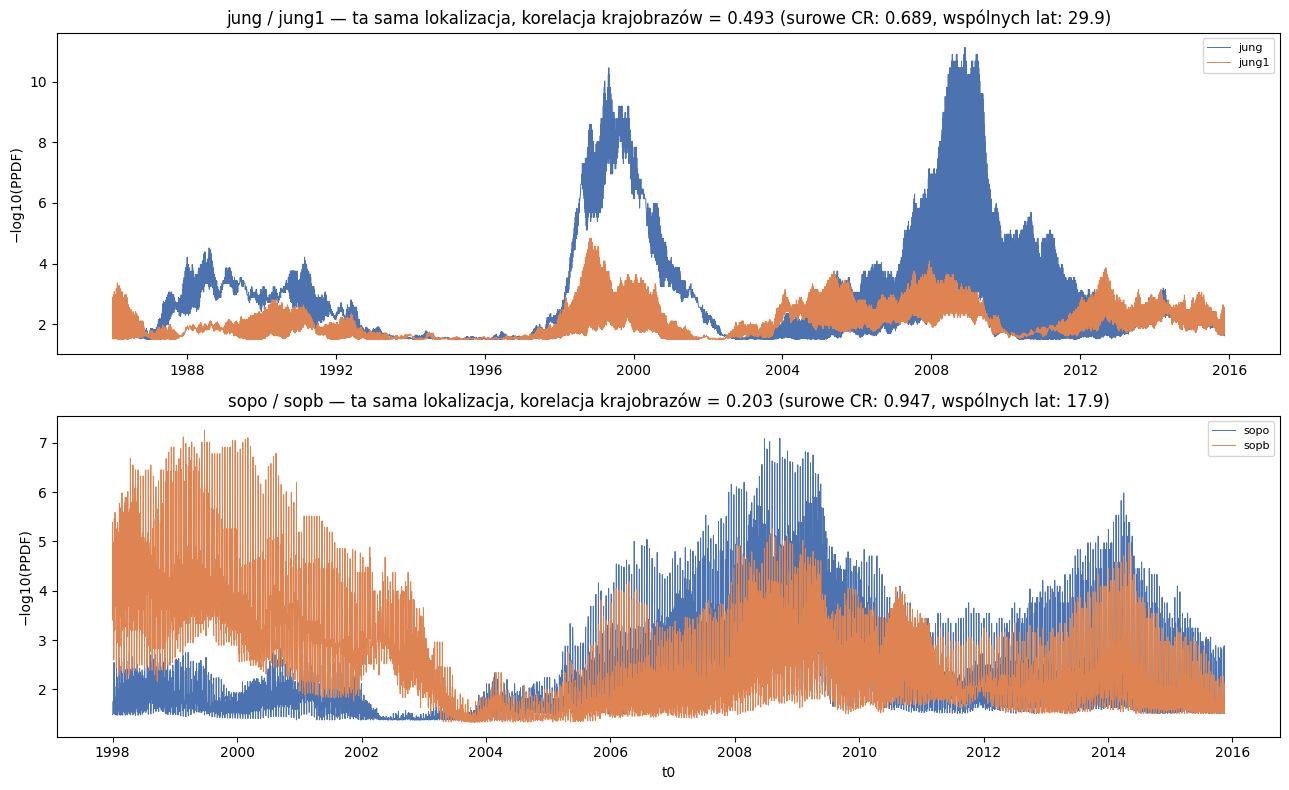

In [13]:
# Kontrola par wspolokolowanych - naturalny test niezaleznosci, ktorego
# dotad nie robilismy. jung/jung1 stoja na tym samym szczycie, sopo/sopb na
# tym samym biegunie. Jesli krzywa -log10 PPDF mierzy fizyke promieniowania
# kosmicznego w danym punkcie Ziemi, to te pary POWINNY dawac niemal
# identyczne krzywe. Rysujemy je obok siebie, zeby bylo widac, czy tak jest.
#
# Uwaga interpretacyjna (wazna przy czytaniu wykresu): wysoka korelacja
# SUROWYCH danych CR tych par bierze sie glownie z powolnej modulacji
# slonecznej, a skladnik B statystyki to RÓŻNICA kolejnych 5-dniowych
# srednich - wielkosc zdominowana przez szum zliczen i lokalne poprawki, w
# ktorej stacje sa duzo mniej podobne. Rozjazd krzywych nie jest wiec sam w
# sobie dowodem bledu; jest miara tego, jak bardzo wynik zalezy od
# pojedynczego detektora.
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, (a, b) in zip(axes, [("jung", "jung1"), ("sopo", "sopb")]):
    wspolne = landscape[[a, b]].dropna()
    krok = max(1, len(wspolne) // 4000)  # przerzedzenie do ~4000 punktow
    w = wspolne.iloc[::krok]
    ax.plot(w.index, w[a], lw=0.7, color="#4C72B0", label=a)
    ax.plot(w.index, w[b], lw=0.7, color="#DD8452", label=b)
    ax.set_ylabel("−log10(PPDF)")
    ax.set_title(f"{a} / {b} — ta sama lokalizacja, korelacja krajobrazów = "
                 f"{corr_landscape.loc[a, b]:.3f} "
                 f"(surowe CR: {corr_cr.loc[a, b]:.3f}, wspólnych lat: "
                 f"{overlap_years.loc[a, b]:.1f})")
    ax.legend(fontsize=8)
axes[-1].set_xlabel("t0")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_landscape_colocated_pairs.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/station_landscape_colocated_pairs.png")


In [14]:
# Kontrola do wniosku z wykresu par wspolokolowanych (komorka 12): tam widac,
# ze jung i jung1 maja struktury w TYCH SAMYCH miejscach osi czasu, ale o
# amplitudach roznych 2-3x w -log10 PPDF (czyli o wiele rzedow wielkosci w
# samym PPDF). Korelacja Pearsona na surowej krzywej jest zdominowana przez
# amplitude, wiec ZANIZA zgodnosc co do POLOZENIA minimow - a to polozenie
# jest tym, o czym mowi Fig.4 artykulu.
#
# Sprawdzamy to wprost: powtarzamy caly rachunek k_eff na korelacji
# Spearmana (rangowej), ktora jest niewrazliwa na monotoniczne
# przeskalowanie amplitudy. Jesli k_eff wyjdzie podobne albo NIZSZE, wniosek
# "siec niesie ~2 niezalezne informacje" jest odporny na ten zarzut.
# Uwaga na koszt: rangowanie 20 kolumn x ~74 tys. wierszy parami - kilkanascie
# do kilkudziesieciu sekund, nie sekundy.
import time

_t = time.time()
corr_spearman = landscape.corr(method="spearman", min_periods=MIN_OVERLAP_SAMPLES)
print(f"Macierz Spearmana policzona w {time.time() - _t:.0f} s")

rows_sp = []
for nazwa, stacje in PODZBIORY.items():
    blok = landscape[list(stacje)].dropna()
    if len(blok) < MIN_OKNO_PROBEK:
        continue
    C_p = blok.corr(method="pearson")
    C_s = blok.corr(method="spearman")
    k_p, _ = k_eff_from_corr(C_p)
    k_s, _ = k_eff_from_corr(C_s)
    iu_s = np.triu_indices(len(stacje), k=1)
    rows_sp.append(dict(podzbior=nazwa, n_stacji=len(stacje),
                        srednia_korelacja_pearson=round(float(C_p.to_numpy()[iu_s].mean()), 3),
                        srednia_korelacja_spearman=round(float(C_s.to_numpy()[iu_s].mean()), 3),
                        k_eff_pearson=round(k_p, 2), k_eff_spearman=round(k_s, 2)))

keff_spearman = pd.DataFrame(rows_sp)
keff_spearman.to_csv(f"{RESULTS_DIR}/station_landscape_keff_spearman.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/station_landscape_keff_spearman.csv")
print()
print(keff_spearman.to_string(index=False))
print()
print("Pary wspolokolowane w obu miarach (Spearman odporny na amplitude):")
for a, b, opis in PARY_KONTROLNE:
    print(f"  {a}-{b}: Pearson {corr_landscape.loc[a, b]:.3f}, "
          f"Spearman {corr_spearman.loc[a, b]:.3f}   ({opis})")
print()
print("Czytanie: jesli Spearman jest WYRAZNIE wyzszy od Pearsona dla par")
print("wspolokolowanych, to potwierdza odczyt z wykresu - stacje zgadzaja sie")
print("co do polozenia struktur, a roznia co do ich sily. Dla wniosku o")
print("niezaleznosci liczy sie wtedy k_eff ze Spearmana, bo to polozenie")
print("minimow jest trescia twierdzenia z Fig.4.")


Macierz Spearmana policzona w 0 s
Zapisano ../results/station_landscape_keff_spearman.csv

        podzbior  n_stacji  srednia_korelacja_pearson  srednia_korelacja_spearman  k_eff_pearson  k_eff_spearman
    wszystkie_20        20                      0.678                       0.634           1.90            2.08
     19_bez_psnm        19                      0.586                       0.559           2.24            2.40
18_bez_psnm_hrms        18                      0.554                       0.522           2.44            2.68
  dlugie_od_1975         9                      0.633                       0.635           1.99            2.07
 dlugie_bez_hrms         8                      0.584                       0.596           2.18            2.24

Pary wspolokolowane w obu miarach (Spearman odporny na amplitude):
  jung-jung1: Pearson 0.493, Spearman 0.421   (ten sam szczyt Jungfraujoch)
  sopo-sopb: Pearson 0.203, Spearman 0.230   (ten sam biegun poludniowy)
  aatb-hrms: P